# STAT207 Mini-Project #1 - The Bachelor Dataset 


Mahlet Abebe

In [118]:
#Imports here
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

## 1. Introduction

My research question for this project is 'How does the nature of the relationship between `Age` and `Occupation` change for different values of `Eliminated` in the dataset?"

I chose this question because I want to determine whether a contestant's age and occupation have an impact on how long they remain on the show. Furthermore, figuring out this association may help determine whether particular age groups or job kinds have a higher chance of winning the competition. One set of people that might benefit from this research would be "The Bachelor" producers and casting directors. Using this knowledge, they  can modify hiring practices to keep viewers interested and increase ratings. They can promote diversity by using this research as well. 

## 2. Dataset Discussion

The source of my csv file was Kaggle.com. Here is a link to it: https://www.kaggle.com/datasets/mexwell/the-bachelor-contestants. I downloaded this dataset on February 16, 2024. 

Each row in this dataset represents a different Bachelor contestant and the information in this dataset was most likely collected via Wikipedia pages related to the show. 

Although there are a lot of rows/observations in this dataset, it isn't inclusive of all possible types of observations because there are 29 seasons of the Bachelor with 20-30 contestants per season. In additon to this, the description of the dataset states that data was avaliable for seasons 1, 2, 5, and seasons 9 through 21, which is just 5 out of 29 seasons. Therefore, the data shown here offers us a limited amount of contestants. 

The dataset only covers a portion of the seasons, so a casting director should proceed with caution when estimating trends from the results. The data may not accurately represent contestant success trends over all seasons. They may therefore utilize the data as a starting point but look for additional  datasets before making significant casting decisions.

The three variables that I will be exploring in this analysis are 'Age', 'Occupation', and 'Eliminated'. 'Age' represents the age of the contestants during their time on the show, 'Occupation' represents their job, and 'Eliminated' represents the time in which they left the competition. 


In [119]:
df = pd.read_csv('historical_bachelor_contestants.csv')
df

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Outcome,Season
0,0,23.0,Winner,"Chanute, Kansas",Amanda Marsh,Event Planner,NaN,1
1,1,29.0,Runner-Up,"Miami, Florida",Trista Rehn,Miami Heat Dancer,NaN,1
2,2,24.0,Week 5,"Dallas, Texas",Shannon Oliver,Financial Management Consultant,NaN,1
3,3,24.0,Week 4,"Tempe, Arizona",Kim,Nanny,NaN,1
4,4,22.0,Week 3,"Terra Haute, Indiana",Cathy Grimes,Graduate Student,NaN,1
...,...,...,...,...,...,...,...,...
474,26,28.0,NaN,"Plano, Texas",Erin Landry,Human Resources Manager,Week 1,23
475,27,26.0,NaN,"West Hollywood, California","Adrianne ""Jane"" Aver",Social Worker,Week 1,23
476,28,26.0,NaN,"Dallas, Texas",Laura Pellerito,Accountant,Week 1,23
477,29,24.0,NaN,"Austin, Texas",Revian Chang,Nurse,Week 1,23


In [120]:
df.head(5)

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Outcome,Season
0,0,23.0,Winner,"Chanute, Kansas",Amanda Marsh,Event Planner,NaN,1
1,1,29.0,Runner-Up,"Miami, Florida",Trista Rehn,Miami Heat Dancer,NaN,1
2,2,24.0,Week 5,"Dallas, Texas",Shannon Oliver,Financial Management Consultant,NaN,1
3,3,24.0,Week 4,"Tempe, Arizona",Kim,Nanny,NaN,1
4,4,22.0,Week 3,"Terra Haute, Indiana",Cathy Grimes,Graduate Student,NaN,1


In [121]:
df.shape[0]

479

## 3. Dataset Cleaning

In [122]:
df['Age'].unique()

array([23., 29., 24., 22., 28., 27., 25., 30., 31., 26., 33., 21., 34.,
       nan, 32., 35., 36.])

In [123]:
df['Unnamed: 0'].unique()


array([ 0,  1,  2,  3,  4,  5,  6,  7,  8,  9, 10, 11, 12, 13, 14, 15, 16,
       17, 18, 19, 20, 21, 22, 23, 24, 25, 26, 27, 28, 29, 30])

In [124]:
df['Eliminated'].unique()

array(['Winner', 'Runner-Up', 'Week 5', 'Week 4', 'Week 3', 'Week 2',
       'Week 1', 'Week 6', 'Week 2 (Quit)', 'Week 7', 'Week 8', nan],
      dtype=object)

In [125]:
df['Hometown'].unique()

array(['Chanute, Kansas', 'Miami, Florida', 'Dallas, Texas',
       'Tempe, Arizona', 'Terra Haute, Indiana', 'Bonita, California',
       'Los Angeles, California', 'Woodward, Oklahoma',
       'Beverly Hills, California', 'New York, New York',
       'Avondale, Arizona', 'Burbank, California',
       'Malden, Massachusetts', 'Plano, Texas', 'Seattle, Washington',
       'Honolulu, Hawaii', 'Pittsburgh, Pennsylvania',
       'Chicago, Illinois', 'Swansea, Massachusetts',
       'Eastchester, New York', 'Gloucester, New Jersey',
       'Albertville, Alabama', 'Philadelphia, Pennsylvania',
       'Kansas City, Missouri', 'Lake Oswego, Oregon', 'Boise, Idaho',
       'Walnut Creek, California', 'Midvale, Utah',
       'Long Island, New York', 'Westchester, Pennsylvania',
       'Redondo Beach, California', 'San Francisco, California',
       'Chapel Hill, North Carolina', 'Granite City, Illinois',
       'Houston, Texas', 'Long Beach, California',
       'Coral Gables, Florida', 'Forked 

In [126]:
df['Occupation'].unique()

array(['Event Planner', 'Miami Heat Dancer',
       'Financial Management Consultant', 'Nanny', 'Graduate Student',
       'Attorney', 'Actress', 'Commercial Real Estate Agent',
       'Special Ed. Teacher', 'Production Coordinator',
       'Hooters Waitress', 'Power Tool Sales Rep.', 'Photographer',
       'Business Development Director', 'Neuropsychologist', 'Doctor',
       'Bar Manager', 'Retail Manager', 'Advertising Executive',
       'Insurance Representative', '6th Grade Teacher',
       'Technology Specialist', 'School Psychologist', 'College Student',
       'Executive Recruiter', 'Registered Nurse', 'Flight Attendant',
       'Assistant Financial Advisor', 'Marriage Therapy Trainee',
       'Airline Supervisor', 'Graphic Artist', 'Radio Sales',
       'Publications Quality Control', 'Strategic Planning Analyst',
       'Psychologist', '3rd Grade Teacher', 'Radiological Technologist',
       'Interior Designer', 'Paralegal', 'Former NBA Cheerleader',
       '1st Grade Teacher

In [127]:
df['Outcome'].unique()

array([nan, 'Winner', 'Runner-up', 'Week 7', 'Week 6', 'Week 5', 'Week 4',
       '9', 'Week 3', 'Week 2', 'Week 1', '12', '15 (quit)', '8',
       '15 (DQ)', 'Week 9', 'Week 8', '6', '11', '17 (quit)', '8 (DQ)',
       '13', '16 (quit)', '16', '19 (quit)', '6 (quit)', '18', '15',
       '[34][37]', '[34]', '14', '21 (quit)', 'Participating',
       'Week 7 (quit)', 'Week 6 (quit)', 'Week 5 (quit)'], dtype=object)

In [128]:
dfbachelor = pd.read_csv('historical_bachelor_contestants.csv', na_values=['NaN']) 
dfbachelor = dfbachelor.dropna(subset=['Eliminated', 'Age'])
dfbachelor



,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Outcome,Season
0,0,23.0,Winner,"Chanute, Kansas",Amanda Marsh,Event Planner,NaN,1
1,1,29.0,Runner-Up,"Miami, Florida",Trista Rehn,Miami Heat Dancer,NaN,1
2,2,24.0,Week 5,"Dallas, Texas",Shannon Oliver,Financial Management Consultant,NaN,1
3,3,24.0,Week 4,"Tempe, Arizona",Kim,Nanny,NaN,1
4,4,22.0,Week 3,"Terra Haute, Indiana",Cathy Grimes,Graduate Student,NaN,1
...,...,...,...,...,...,...,...,...
147,20,24.0,Week 1,"Tempe, Arizona",Morgan Becker,Graduate student,NaN,11
148,21,25.0,Week 1,"Duncanville, Texas",Natalie Velasco,Law student,NaN,11
149,22,31.0,Week 1,"San Diego, California",Regina Doringa,Account representative,NaN,11
150,23,31.0,Week 1,"St. Louis Park, Minnesota",Tauni Nessler [11],Emergency room nurse,NaN,11


In [129]:
dfbachelor = dfbachelor.drop(columns=['Outcome'])
dfbachelor



,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
0,0,23.0,Winner,"Chanute, Kansas",Amanda Marsh,Event Planner,1
1,1,29.0,Runner-Up,"Miami, Florida",Trista Rehn,Miami Heat Dancer,1
2,2,24.0,Week 5,"Dallas, Texas",Shannon Oliver,Financial Management Consultant,1
3,3,24.0,Week 4,"Tempe, Arizona",Kim,Nanny,1
4,4,22.0,Week 3,"Terra Haute, Indiana",Cathy Grimes,Graduate Student,1
...,...,...,...,...,...,...,...
147,20,24.0,Week 1,"Tempe, Arizona",Morgan Becker,Graduate student,11
148,21,25.0,Week 1,"Duncanville, Texas",Natalie Velasco,Law student,11
149,22,31.0,Week 1,"San Diego, California",Regina Doringa,Account representative,11
150,23,31.0,Week 1,"St. Louis Park, Minnesota",Tauni Nessler [11],Emergency room nurse,11


In [130]:
df.shape[0] - dfbachelor.shape[0]

328

After dropping 328 rows of  missing values from the dataset, I am now down to only 151 rows. 

In [131]:
dfbachelor.isnull().mean() * 100


Unnamed: 0    0.0
Age           0.0
Eliminated    0.0
Hometown      0.0
Name          0.0
Occupation    0.0
Season        0.0
dtype: float64

My dataset doesn't have implicit missing values, but it has explicit missing values so I ended up dropping my entire 'Outcome' column as there were too many missing values and I felt that the information in there served the same purpose as the 'Eliminated' column. Additionally, I dropped the explicit missing values in the rest of the columns. Some benefits of this technique include a cleaner dataset and an improved analysis, especially because you don't have to account for  misleading data. However, some downsides to this are that due to the removal of data, we'll end up with a smaller sample size, which can leading to bias. As a matter of fact, my new dataset has less than half of the rows of my original dataset as I had to drop 328 rows. 

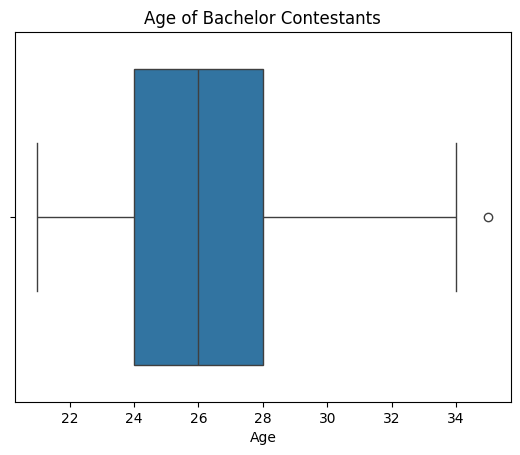

In [132]:
sns.boxplot(data=dfbachelor, x='Age')
plt.title('Age of Bachelor Contestants')
plt.show()

In [133]:
dropbachelor = dfbachelor[dfbachelor['Age'] <= 34]
dropbachelor


,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
0,0,23.0,Winner,"Chanute, Kansas",Amanda Marsh,Event Planner,1
1,1,29.0,Runner-Up,"Miami, Florida",Trista Rehn,Miami Heat Dancer,1
2,2,24.0,Week 5,"Dallas, Texas",Shannon Oliver,Financial Management Consultant,1
3,3,24.0,Week 4,"Tempe, Arizona",Kim,Nanny,1
4,4,22.0,Week 3,"Terra Haute, Indiana",Cathy Grimes,Graduate Student,1
...,...,...,...,...,...,...,...
146,19,28.0,Week 1,"Westchester, New York",Melissa Buschel[12],Event planner,11
147,20,24.0,Week 1,"Tempe, Arizona",Morgan Becker,Graduate student,11
148,21,25.0,Week 1,"Duncanville, Texas",Natalie Velasco,Law student,11
149,22,31.0,Week 1,"San Diego, California",Regina Doringa,Account representative,11


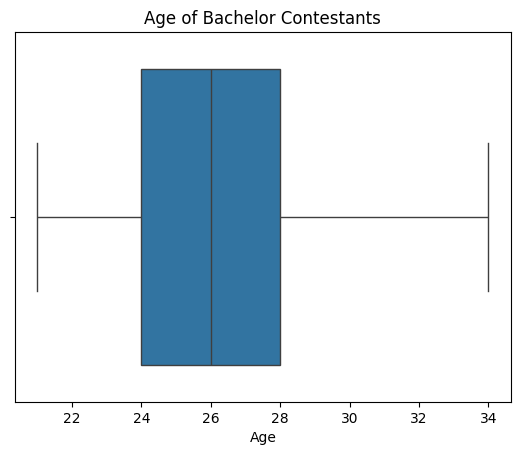

In [134]:
sns.boxplot(data=dropbachelor, x='Age')
plt.title('Age of Bachelor Contestants')
plt.show()

In [135]:
dfbachelor.shape[0] - dropbachelor.shape[0]

1

I ended up having to drop one outlier for 'Age' in order to increase the accuracy of my research. 

## 4. <u>Research Question</u>: How does the Relationship between `Age` and `Occupation` Change based on Different Values of `Eliminated` in the Dataset?

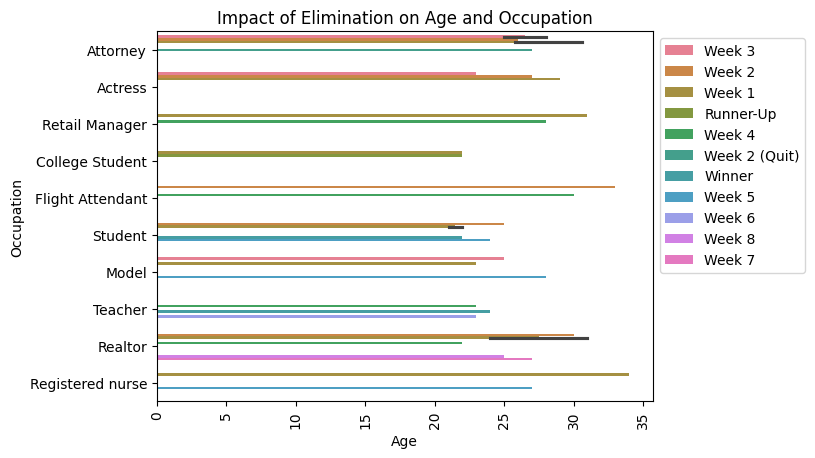

In [143]:
topoccupations = dropbachelor['Occupation'].value_counts().head(10).index
filteredocc = dfbachelor[dfbachelor['Occupation'].isin(topoccupations)]
sns.barplot(x='Age', y='Occupation', hue='Eliminated', data=filteredocc)
plt.title('Impact of Elimination on Age and Occupation')
plt.xticks(rotation=90)  
plt.legend(bbox_to_anchor=(1,1))
plt.show()


In [138]:
filteredocc['Age'].describe()


count    38.000000
mean     26.342105
std       3.481816
min      21.000000
25%      23.250000
50%      26.000000
75%      28.750000
max      34.000000
Name: Age, dtype: float64

In [148]:
print(filteredocc.columns)


Index(['Unnamed: 0', 'Age', 'Eliminated', 'Hometown', 'Name', 'Occupation',
       'Season'],
      dtype='object')


# Top Contestants

In [155]:
winners = filteredocc[filteredocc["Eliminated"] == "Winner"]
winnersmean = winners["Age"].mean()
winnersmean

np.float64(23.0)

In [170]:
winners = filteredocc[filteredocc["Eliminated"] == "Winner"]
winners

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
50,0,22.0,Winner,"Huntington Beach, California",Jessica Bowlin,Student,5
75,0,24.0,Winner,"Pembroke Pines, Florida",Jennifer Wilson,Teacher,9


In [163]:
week8 = filteredocc[filteredocc["Eliminated"] == "Week 8"]
week8mean = week8["Age"].mean()
week8mean

np.float64(25.0)

In [171]:
week8 = filteredocc[filteredocc["Eliminated"] == "Week 8"]
week8

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
127,0,25.0,Week 8,"Newnan, Georgia",Deanna Pappas[1],Realtor,11


In [164]:
week7 = filteredocc[filteredocc["Eliminated"] == "Week 7"]
week7mean = winners["Age"].mean()
week7mean

np.float64(23.0)

In [172]:
week7 = filteredocc[filteredocc["Eliminated"] == "Week 7"]
week7

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
129,2,27.0,Week 7,"Washington, D.C.",Bettina Bell[2],Realtor,11


In [177]:
week6 = filteredocc[filteredocc["Eliminated"] == "Week 6"]
week6mean = winners["Age"].mean()
week6mean

np.float64(23.0)

In [178]:
week6 = filteredocc[filteredocc["Eliminated"] == "Week 6"]
week6

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
105,3,23.0,Week 6,"Sugar Land, Texas",Amber Alchalabi,Teacher,10


In [179]:
week5 = filteredocc[filteredocc["Eliminated"] == "Week 5"]
week5mean = winners["Age"].mean()
week5mean

np.float64(23.0)

In [180]:
week5 = filteredocc[filteredocc["Eliminated"] == "Week 5"]
week5

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
53,3,28.0,Week 5,"Atlanta, Georgia",Trish Schneider,Model,5
78,3,24.0,Week 5,"Venice, Italy",Agnese Polliza,Student,9
131,4,27.0,Week 5,"Philadelphia, Pennsylvania",Hillary Reisinger[4],Registered nurse,11


# Bottom Contestants

In [168]:
week1 = filteredocc[filteredocc["Eliminated"] == "Week 1"]
week1mean = week1["Age"].mean()
week1mean

np.float64(26.928571428571427)

In [169]:
week1 = filteredocc[filteredocc["Eliminated"] == "Week 1"]
week1

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
19,19,31.0,Week 1,"Chicago, Illinois",Jill,Retail Manager,1
21,21,29.0,Week 1,"Dallas, Texas",Lisa,Attorney,1
41,16,29.0,Week 1,"Los Angeles, California",Camille,Actress,2
45,20,22.0,Week 1,"Long Beach, California",Fatima,College Student,2
71,21,21.0,Week 1,"Cincinnati, Ohio",Jessica Kyron,Student,5
87,12,24.0,Week 1,"St. Augustine, Florida",Tara Durr,Realtor,9
91,16,27.0,Week 1,"Biloxi, MS",Meri Barr,Attorney,9
94,19,34.0,Week 1,"Aliquippa, PA",Heather Sneed,Registered nurse,9
98,23,25.0,Week 1,"Cattaraugus, NY",Carissa Ilburg,Attorney,9
101,26,23.0,Week 1,"Chicago, IL",April Jacobs,Model,9


In [173]:
week2 = filteredocc[filteredocc["Eliminated"] == "Week 2"]
week2mean = week2["Age"].mean()
week2mean

np.float64(28.5)

In [174]:
week2 = filteredocc[filteredocc["Eliminated"] == "Week 2"]
week2

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
11,11,27.0,Week 2,"Burbank, California",Angelique,Actress,1
37,12,33.0,Week 2,"Redondo Beach, California",Suzanne,Flight Attendant,2
65,15,25.0,Week 2,"Dearborn, Michigan",Kristy Romero,Student,5
86,11,30.0,Week 2,"New Haven, Connecticut",Ellen DeMaio,Realtor,9
114,12,26.0,Week 2,"Southlake, Texas",Alexis Young,Attorney,10
139,12,30.0,Week 2,"South Brunswick, New Jersey",Michele Leavy[10],Realtor,11


In [175]:
week3 = filteredocc[filteredocc["Eliminated"] == "Week 3"]
week3mean = week3["Age"].mean()
week3mean

np.float64(25.25)

In [176]:
week3 = filteredocc[filteredocc["Eliminated"] == "Week 3"]
week3

,Unnamed: 0,Age,Eliminated,Hometown,Name,Occupation,Season
5,5,28.0,Week 3,"Bonita, California",Christina,Attorney,1
6,6,23.0,Week 3,"Los Angeles, California",LaNease Adams,Actress,1
56,6,25.0,Week 3,"Pearsall, Texas",Jessica Holcomb,Attorney,5
136,9,25.0,Week 3,"Livonia, Michigan",Lindsey Hawkins,Model,11


Yes, there is a slight relationship between 'age', 'occupation', and 'eliminated' in this dataset. A lot of the contestants who make it further tend to be younger. However, the occupations of the contestants are varied all across their time on the show. 

Although the median age of all participants is 26, the median age of contestants in each occupation tends to vary. In my barplot, I noticed that many of the  participants who were older than our mean age of 26 tended to be eliminated sooner, while the younger contestants tended to stay on the show longer. Most of the contestants who would make it to the final four in their respective seasons were around 22-25 years old, suggesting that bachelors tend to favor younger women. 

For some jobs, such as teachers and realtors, the age distribution is wider, suggesting that a wider range of contestants fall into these occupations. The age range is narrower for jobs such as models and students, therefore the majority of participants in these categories are young. There is a greater age distribution in some elimination weeks, which may indicate that occupation and age do not always predict when elimination will occur.



The distribution of ages tended to be skewed to the right, meaning that the ages of the majority of contestants were below the mean. As the weeks pass, we gradually begin to notice a concentration of younger contestants because the majority of the older contestants are eliminated earlier. As a result, in the following weeks, we begin to observe a more symmetrical and balanced distribution. 

Contestants with certain occupations such as realtors and attorneys include possible outliers on the higher end of the age spectrum, meaning some significantly older contestants participated. However occupations such as 'student' and 'model' generally do not exhibit high-age outliers as the age of those contestants generally tend to lie around our mean of 26. 




## 5. Conclusion

The relationship between Age and Occupation varies based on the Eliminated values; younger participants (like models and students) are eliminated later in the competition, whereas older candidates in professional roles (like lawyers and realtors) tend to be eliminated earlier.

Some of the shortcomings that I had in this analysis are that I had to drop a majority of the values within my columns as well as an entire column due to the abundance of explicit missing values in my dataset. This is significant as casting directors may overestimate trends that are actually the result of missing data rather than actual patterns if they use this approach to choose contestants. This could result in poor casting choices based on lack of data. An idea that I have for similar future projects would be using machine learning algorithims to predict the output of missing values based on current features in our dataset. 

